# **Homework 5:** Precipitation Nowcasting using Neural Networks

In this exercise, you are going to build a set of deep learning models on a real world task using PyTorch. PyTorch is an open source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab (FAIR).

## **Setting up to use the GPU**

Before we start, we need to change the environment of Colab to use GPU. Do so by:

Runtime -> Change runtime type -> Hardware accelerator -> GPU

---

## **Deep Neural Networks with PyTorch**

To complete this exercise, you will need to build deep learning models for precipitation nowcasting. You will build a subset of the models shown below:
- Fully Connected (Feedforward) Neural Network
- Two-Dimentional Convolution Neural Network (2D-CNN)
- Recurrent Neural Network with Gated Recurrent Unit (GRU)

and one more model of your choice to achieve the highest score possible.

We provide the code for data cleaning and some starter code for PyTorch in this notebook but feel free to modify those parts to suit your needs. Feel free to use additional libraries (e.g. scikit-learn) as long as you have a model for each type mentioned above.

This notebook assumes you have already installed PyTorch with python3 and had GPU enabled. If you run this exercise on Colab you are all set.

---

## **Precipitation Nowcasting**

Precipitation nowcasting is the the task of predicting the amount of rainfall in a certain region given some kind of sensor data. The term nowcasting refers to tasks that try to predict the current or near future conditions (within 6 hours).

You will be given satellite images in 3 different bands covering a 5 by 5 region from different parts of Thailand. In other words, your input will be a $ 5 \times 5 \times 3 $ image. Your task is to predict the amount of rainfall in the center pixel. You will first do the prediction using just a simple fully-connected neural network that view each pixel as different input features.

Since the your input is basically an image, we will then view the input as an image and apply CNN to do the prediction. Finally, we can also add a time component since weather prediction can benefit greatly using previous time frames. Each data point actually contain 5 time steps, so each input data point has a size of $ 5 \times 5 \times 5 \times 3 $ (time x height x width x channel), and the output data has a size of 5 (time). You will use this time information when you work with RNNs.

Finally, we would like to thank the Thai Meteorological Department for providing the data for this assignment.

In [1]:
!nvidia-smi

Tue Mar 17 02:34:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.65                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   68C    P8             12W /   95W |     199MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---

## **Weights and Biases**

[Weights and Biases](https://docs.wandb.ai/company) (wandb) is an experiment tracking tool for machine learning. It can log and visualize experiments in real time. It supports many popular ML frameworks, and obviously PyTorch is one of them. In this notebook you will learn how to log general metrics like losses, parameter distributions, and gradient distribution with wandb.

---

## **Setup**

1. Register [Wandb account](https://wandb.ai/login?signup=true) (and confirm your email)

2. `wandb login` and copy paste the API key when prompt

In [2]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nodahttap/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [3]:
import os
import random
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from sklearn import preprocessing
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchinfo import summary

from tqdm import tqdm as tqdm

torch.__version__

'2.10.0+cu128'

In [4]:
SEED = 42

# Python built-in RNG
random.seed(SEED)

# NumPy RNG
np.random.seed(SEED)

# Python hash seed (affects some reproducibility cases)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Check if CUDA is available
print(f"CUDA available: {torch.cuda.is_available()}")

# PyTorch RNG
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

CUDA available: True


---

## **Loading the data**

The data is on huggingface, a website that allows people to share datasets and pretrained models.

In [5]:
from huggingface_hub import hf_hub_download

hf_hub_download(repo_id="ecitslos/HWnowcastingdata", filename="nowcastingHWdataset.tar.gz", repo_type="dataset", local_dir=".")

'nowcastingHWdataset.tar.gz'

In [6]:
!tar -xvf "./nowcastingHWdataset.tar.gz"

dataset/features-m10.pk
dataset/features-m6.pk
dataset/features-m7.pk
dataset/features-m8.pk
dataset/features-m9.pk
dataset/labels-m10.pk
dataset/labels-m6.pk
dataset/labels-m7.pk
dataset/labels-m8.pk
dataset/labels-m9.pk


---

## **Data Explanation**

The data is an hourly measurement of water vapor in the atmosphere, and two infrared measurements of cloud imagery on a latitude-longitude coordinate. Each measurement is illustrated below as an image. These three features are included as different channels in your input data.

<img src="../images/wvapor.png" width="200"> <img src="../images/cloud1.png" width="200"> <img src="../images/cloud2.png" width="200">

We also provide the hourly precipitation (rainfall) records in the month of June, July, August, September, and October from weather stations spreaded around the country. A $ 5 \times 5 $ grid around each weather station at a particular time will be paired with the precipitation recorded at the corresponding station as input and output data. Finally, five adjacent timesteps are stacked into one sequence.

The month of June-August are provided as training data, while the months of September and October are used as validation and test sets, respectively.

---

## **Reading data**

In [7]:
def read_data(months, data_dir="dataset"):
    features = np.array([], dtype=np.float32).reshape(0, 5, 5, 5, 3)
    labels = np.array([], dtype=np.float32).reshape(0, 5)
    for m in months:
        filename = "features-m{}.pk".format(m)
        with open(os.path.join(data_dir, filename), "rb") as file:
            features_temp = pickle.load(file)
        features = np.concatenate((features, features_temp), axis=0)

        filename = "labels-m{}.pk".format(m)
        with open(os.path.join(data_dir, filename), "rb") as file:
            labels_temp = pickle.load(file)
        labels = np.concatenate((labels, labels_temp), axis=0)

    return features, labels

In [8]:
# use data from month 6, 7, 8 as training set
x_train, y_train = read_data(months=[6, 7, 8])

# use data from month 9 as validation set
x_val, y_val = read_data(months=[9])

# use data from month 10 as test set
x_test, y_test = read_data(months=[10])

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape, "\n")
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape, "\n")
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (229548, 5, 5, 5, 3)
y_train shape: (229548, 5) 

x_val shape: (92839, 5, 5, 5, 3)
y_val shape: (92839, 5) 

x_test shape: (111715, 5, 5, 5, 3)
y_test shape: (111715, 5)


**features**
- dim 0: number of entries
- dim 1: number of time-steps in ascending order
- dim 2, 3: a $ 5 \times 5 $ grid around rain-measued station
- dim 4: water vapor and two cloud imagenaries

**labels**
- dim 0: number of entries
- dim 1: number of precipitation for each time-step

---

## **Three-Layer Feedforward Neural Networks**

In [9]:
# Dataset need to be reshaped to make it suitable for feedforword model
def preprocess_for_ff(x_train, y_train, x_val, y_val, x_test, y_test):
    x_train_ff = x_train.reshape((-1, 5 * 5 * 3))
    y_train_ff = y_train.reshape((-1, 1))
    x_val_ff = x_val.reshape((-1, 5 * 5 * 3))
    y_val_ff = y_val.reshape((-1, 1))
    x_test_ff = x_test.reshape((-1, 5 * 5 * 3))
    y_test_ff = y_test.reshape((-1, 1))

    return x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff

x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff = preprocess_for_ff(x_train, y_train, x_val, y_val, x_test, y_test)

print(x_train_ff.shape, y_train_ff.shape)
print(x_val_ff.shape, y_val_ff.shape)
print(x_test_ff.shape, y_test_ff.shape)

(1147740, 75) (1147740, 1)
(464195, 75) (464195, 1)
(558575, 75) (558575, 1)


In [10]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(229548, 5, 5, 5, 3)
(229548, 5)
(92839, 5, 5, 5, 3)
(92839, 5)


---

### **T1.**
Explain each line of code in the function `preprocess_for_ff()`

**Ans:** The function `preprocess_for_ff()` is designed to reshape the input data for a fully connected (feedforward) neural network. The function takes in the training, validation, and test datasets (both features and labels) and reshapes them into a format suitable for feeding into a fully connected neural network.

```python
def preprocess_for_ff(x_train, y_train, x_val, y_val):
    # Reshape the training, validation, and test datasets
    # for a **fully connected** neural network.
    # Reshaping is done by flattening the 5x5x3 input
    # into a single vector of size 75 (5*5*3)

    # For the each set of data, reshape the
    # input features (x_train) to have a shape of (number of entries, 75)
    # and the labels (y_train) to have a shape of (number of entries, 1)
    
    x_train_ff = x_train.reshape((-1, 5 * 5 * 3))
    y_train_ff = y_train.reshape((-1, 1))
    x_val_ff = x_val.reshape((-1, 5 * 5 * 3))
    y_val_ff = y_val.reshape((-1, 1))
    x_test_ff = x_test.reshape((-1, 5 * 5 * 3))
    y_test_ff = y_test.reshape((-1, 1))

    return x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff
```

---

## **Dataset**

To prepare a DataLoader in order to feed data into the model, we need to create a `torch.utils.data.Dataset` object first. (Learn more about it [here](https://pytorch.org/docs/stable/data.html#map-style-datasets))

Dataset is a simple class that the DataLoader will get data from, most of its functionality comes from `__getitem__(self, index)` method, which will return a single data point (both input and label). In real world scenarios the method can do some other stuffs such as

1. Load images

If your input (x) are images. Oftentimes you won't be able to fit all the training images into your RAM. Thus, you should pass an array (or list) of image path into the dataloader, and the `__getitem__` will be the one who dynamically loads the actual image from the harddisk for you.


2. Data Normalization

Data normalization helps improve stability of training. Unnormalized data can cause gradients to explode. There are many variants of normalization, but in this notebook we will use either minmax or z-score (std) normalization. Read [this](https://developers.google.com/machine-learning/data-prep/transform/normalization) (or google) if you wish to learn more about data normalization.


3. Data Augmentation

In computer vision, you might want to apply small changes to the images you use in training (adjust brightness, contrast, rotation) so that the model will generalize better on unseen data. There are two kinds of augmentation: static and dynamic. Static augmentation will augment images and save to disk as a new dataset. On the other hand, rather than applying the change initially and use the same change on each image every epoch, dynamic augmentation will augment each data differently for each epoch. Note that augmentation is usually done on the CPU and you might be bounded by the CPU instead. PyTorch has a dedicated [documentation about data augmentation](https://pytorch.org/vision/master/transforms.html) if you want to know more.

In [11]:
class RainfallDatasetFF(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)
        self.normalizer = normalizer
        print(self.x.shape)
        print(self.y.shape)

    def __getitem__(self, index):
        # Retrieve data
        x = self.x[index]
        
        # Normalize
        x = self.normalizer.transform(x.reshape(1, -1))
        
        y = self.y[index]
        
        return x, y

    def __len__(self):
        return self.x.shape[0]

In [12]:
def normalizer_std(X):
    scaler = preprocessing.StandardScaler().fit(X)
    return scaler

def normalizer_minmax(X):
    scaler = preprocessing.MinMaxScaler().fit(X)
    return scaler

In [13]:
# We will normalize everything based on x_train
normalizer = normalizer_std(x_train_ff)

train_dataset = RainfallDatasetFF(x_train_ff, y_train_ff, normalizer)
val_dataset = RainfallDatasetFF(x_val_ff, y_val_ff, normalizer)
test_dataset = RainfallDatasetFF(x_test_ff, y_test_ff, normalizer)

(1147740, 75)
(1147740, 1)
(464195, 75)
(464195, 1)
(558575, 75)
(558575, 1)


---

## **DataLoader**

DataLoader feeds data from our dataset into the model. We can freely customize batch size, data shuffle for each data split, and much more with DataLoader class. If you're curious about what can you do with PyTorch's DataLoader, you can check [this documentation](https://pytorch.org/docs/stable/data.html)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, pin_memory=True)

---

## **Loss Function**

PyTorch has many loss functions readily available for use. We can also write our own custom loss function as well. But for now, we will use [PyTorch's built-in mean squared error loss ](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

In [15]:
loss_fn = nn.MSELoss()

---

### **T2.**
Why is the loss MSE?

**Ans:** MSE (Mean Squared Error) is a common loss function used for regression problems, where the goal is to predict continuous values. In this case, we are trying to predict the amount of rainfall, which is a continuous variable.

MSE calculates the average of the squares of the differences between the predicted values and the actual values.

It penalizes larger errors more than smaller ones, making it suitable for regression tasks where we want to minimize the difference between predicted and actual values.

---

## **Device**

Unlike Tensorflow/Keras, PyTorch allows user to freely put any Tensor or objects (loss functions, models, optimizers, etc.) in CPU or GPU. By default, all objects created will be in CPU. In order to use GPU we will have to supply `device = torch.device("cuda")` into the objects to move it to GPU. You will usually see the syntax like `object.to(device)` for moving CPU object to GPU, or `o = Object(..., device=device)` to create the object in the GPU.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

---

## **Helper Functions**

### **Variable:** `TrainingSkip`

In [17]:
TraingSkip = {
    "model_ff": True,
    "model_ff_dropout": True,
    "model_ff_convolution": True,
    "model_ff_gru": True,
    "model_transformer": False,
    "model_my_model": False,
}

### **Class:** `ModelConfig`

In [18]:
from torchviz import make_dot

class ModelConfig:
    def __init__(self, config_dict, model):
        # Hyperparameters and other configs
        self.config = {
            "architecture": "feedforward",
            "lr": 0.01,
            "hidden_size": 200,
            "scheduler_factor": 0.2,
            "scheduler_patience": 2,
            "scheduler_min_lr": 1e-4,
            "epochs": 10
        }
        
        additional_config = {}
        for key, value in config_dict.items():
            self.config[key] = value
            additional_config[key] = value
        
        additional_config["hidden_size"] = self.config["hidden_size"]
        
        print("Model Config:", additional_config)

        # Model
        self.model = model(**additional_config)
        self.model = self.model.to(device)
        
        # Optimizer and Scheduler
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.config["lr"])
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            "min",
            factor=self.config["scheduler_factor"],
            patience=self.config["scheduler_patience"],
            min_lr=self.config["scheduler_min_lr"]
        )
    
    
    def get_config(self):
        return self.config, self.model, self.optimizer, self.scheduler
    
    
    def make_dot(self, train_loader, save_png=False, save_name="model_architecture", save_dir="../images/model_architecture/"):
        # Visualize model with torchviz
        sample_inputs = next(iter(train_loader))[0].requires_grad_(True)
        sample_y = self.model(sample_inputs.to(device))

        dot = make_dot(sample_y, params=dict(list(self.model.named_parameters()) + [("sample_inputs", sample_inputs)]))
        display(dot)
        
        if save_png:
            dot.render(save_dir + save_name, format="png")
        
        return dot

    
    def print_summary(self, input_size):
        summary_text = summary(self.model, input_size=input_size)
        display(summary_text)

        return summary_text

### **Function:** `load_model()`

In [19]:
def load_model(
    model,
    device=device,
    model_dir="models/",
    results_dir="results/",
    model_name="model_ff"
):
    checkpoint = torch.load(f"{model_dir}{model_name}.pth.tar")
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    
    df = pd.read_csv(f"{results_dir}{model_name}.csv")
    train_losses = df["train_loss"].tolist()
    val_losses = df["val_loss"].tolist()
    learning_rates = df["learning_rate"].tolist()

    return model, train_losses, val_losses, learning_rates

### **Function:** `train_model()`

In [20]:
def train_model(
    config,
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    model_name="model_ff",
    model_dir="models/",
    results_dir="results/",
    loss_fn=nn.MSELoss(),
):
    if (TraingSkip[model_name]):
        print(f"Skipping training for {model_name} as TraingSkip is set to True.")
        
        model, train_losses, val_losses, learning_rates = load_model(model, model_dir=model_dir, results_dir=results_dir, model_name=model_name)
        return train_losses, val_losses, learning_rates
    
    train_losses = []
    val_losses = []
    learning_rates = []

    # Start wandb run
    wandb.init(
        project="precipitation-nowcasting-2026",
        config=config
    )

    # Log parameters and gradients
    # This makes the training slow. Do this when you are debugging only.
    # You should avoid doing this when doing serious training.
    wandb.watch(model, log="all")

    # loop over the dataset multiple times
    for epoch in range(config["epochs"]):

        # Training
        train_loss = []
        current_lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(current_lr)

        # Flag model as training. Some layers behave differently in training and
        # inference modes, such as dropout, BN, etc.
        model.train()

        print(f"Training epoch {epoch + 1}...")
        print(f"Current LR: {current_lr}")

        for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Reset the gradient
            optimizer.zero_grad()

            # Predict
            y_pred = model(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Compute gradient
            loss.backward()

            # Update parameters
            optimizer.step()

            # Log stuff
            train_loss.append(loss)

        avg_train_loss = torch.stack(train_loss).mean().item()
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

        # Validation
        model.eval()
        with torch.no_grad(): # No gradient is required during validation
            print(f"Validating epoch {epoch+1}")
            val_loss = []
            for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
                # Transfer data from cpu to gpu
                inputs = inputs.to(device)
                y_true = y_true.to(device)

                # Predict
                y_pred = model(inputs)

                # Calculate loss
                loss = loss_fn(y_pred, y_true)

                # Log stuff
                val_loss.append(loss)

            avg_val_loss = torch.stack(val_loss).mean().item()
            val_losses.append(avg_val_loss)
            print(f"Epoch {epoch + 1} val loss: {avg_val_loss:.4f}")

            # LR adjustment with scheduler
            scheduler.step(avg_val_loss)

            # Save checkpoint if val_loss is the best we got
            best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
            if avg_val_loss < best_val_loss:
                # Save whatever you want
                state = {
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "train_loss": avg_train_loss,
                    "val_loss": avg_val_loss,
                    "best_val_loss": best_val_loss,
                }

                print(f"Saving new best model..")
                torch.save(state, f"{model_dir}{model_name}.pth.tar")

        wandb.log({
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        })

    wandb.finish()
    print("Finished Training")
    
    df = pd.DataFrame({
        "train_loss": train_losses,
        "val_loss": val_losses,
        "learning_rate": learning_rates
    })
    
    df.to_csv(f"{results_dir}{model_name}.csv", index=False)
    
    return train_losses, val_losses, learning_rates

### **Function:** `plot_losses()`

In [21]:
def plot_losses(
    model,
    config,
    model_dir="models/",
    results_dir="results/",
    model_name="model_ff",
):
    # Load the best model
    model, train_losses, val_losses, _ = load_model(model, model_dir=model_dir, results_dir=results_dir, model_name=model_name)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    epoch = np.arange(1, config["epochs"] + 1)

    ax[0].plot(epoch, train_losses, label="train loss")
    ax[0].set_xticks(epoch)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Train Loss")
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(epoch, val_losses, label="val loss")
    ax[1].set_xticks(epoch)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Validation Loss")
    ax[1].legend()
    ax[1].grid()

    fig.suptitle(f"{model.__class__.__name__} Loss Curves")
    fig.tight_layout()

    fig.savefig(f"../images/{model.__class__.__name__}_loss_curves.png")
    plt.show()

### **Function:** `plot_learning_rates()`

In [22]:
def plot_learning_rates(
    model,
    config,
    model_dir="models/",
    results_dir="results/",
    model_name="model_ff",
):
    # Load the best model
    model, _, _, learning_rates = load_model(model, model_dir=model_dir, results_dir=results_dir, model_name=model_name)

    epoch = np.arange(1, config["epochs"] + 1)

    plt.plot(epoch, learning_rates, label="learning rate")
    plt.xticks(epoch)
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(f"{model.__class__.__name__} Learning Rate Schedule")

    plt.tight_layout()
    plt.legend()
    plt.grid()

    plt.savefig(f"../images/{model.__class__.__name__}_learning_rate_schedule.png")
    plt.show()

---

## **Model**

Below, the code for creating a 3-layers fully connected neural network in PyTorch is provided. Run the code and make sure you understand what you are doing. Then, report the results.

In [23]:
class FeedForwardNN(nn.Module):
    def __init__(self, hidden_size=200):
        super(FeedForwardNN, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1 = F.relu(self.ff1(x))
        hd2 = F.relu(self.ff2(hd1))
        y = F.relu(self.ff3(hd2))
        y = self.out(y)
        
        return y.reshape(-1, 1)

---

### **T3.**
What is the activation function in the final dense layer? and why? Do you think there is a better activation function for the final layer?

**Ans:** The activation function in the final dense layer is ReLU.

For the final layer in a regression problem, it might be more appropriate to use a linear activation function (i.e., no activation function) since we are trying to predict continuous values.

Using ReLU in the final layer could potentially limit the range of predicted values to be non-negative, which may not be suitable for all regression tasks.

---

Model Config: {'hidden_size': 200}


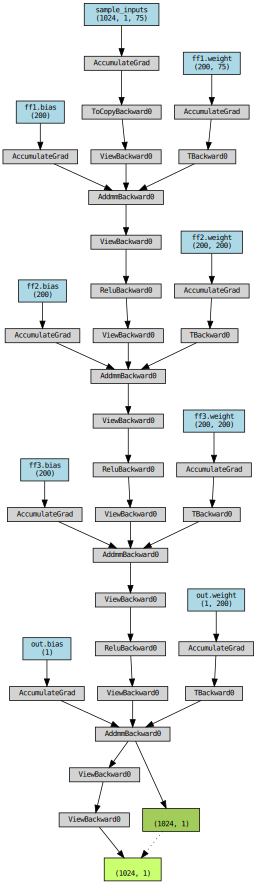

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN                            [1024, 1]                 --
├─Linear: 1-1                            [1024, 200]               15,200
├─Linear: 1-2                            [1024, 200]               40,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
Total params: 95,801
Trainable params: 95,801
Non-trainable params: 0
Total mult-adds (M): 98.10
Input size (MB): 0.31
Forward/backward pass size (MB): 4.92
Params size (MB): 0.38
Estimated Total Size (MB): 5.61

In [24]:
model_config = ModelConfig({}, FeedForwardNN)
config, model_ff, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_loader, save_png=True, save_name="FeedForwardNN", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 75))

---

### **T4.**
Explain why the first linear layer has number of parameters = 15200

**Ans:** The first linear layer has 15200 parameters because it connects the input layer to the first hidden layer. The input layer has 75 features (5x5x3) and the first hidden layer has 200 neurons.

The number of parameters in a linear layer can be calculated using the formula:
\begin{align*}
\text{\# Parameters} &= (\text{\# Input features} \times \text{\# Neurons in the hidden layer}) \\
&\qquad + (\text{\# Neurons in the hidden layer}) \text{ [for bias]} \\
&= (75 \times 200) + 200 \\
&= 15000 + 200 \\
&= 15200
\end{align*}

---

## **Training**

In [25]:
train_losses, val_losses, learning_rates = train_model(
    config,
    model_ff,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    model_name="model_ff"
)

Skipping training for model_ff as TraingSkip is set to True.


You might want to download the saved model (`model_ff.pth.tar`) for later uses if you are running on Colab.

---

### **T5.**
Plot loss and val_loss as a function of epochs.

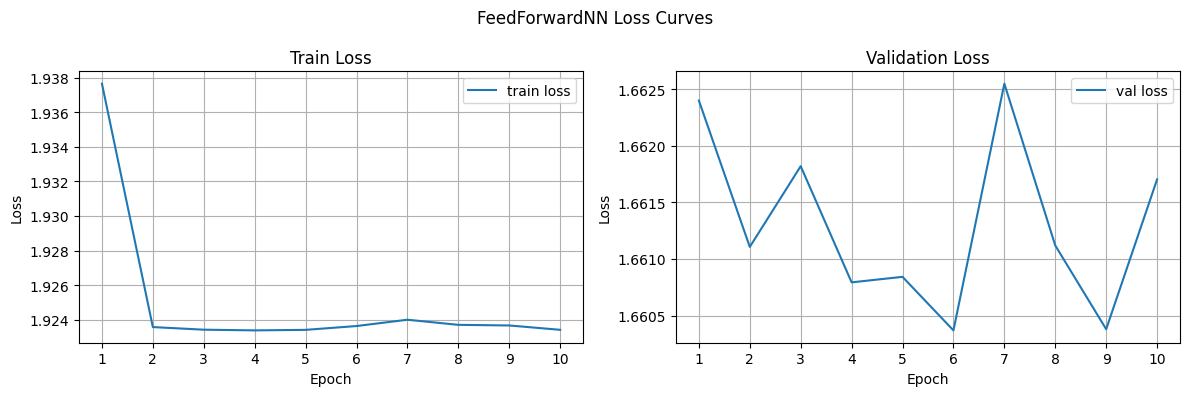

In [26]:
plot_losses(
    model_ff,
    config=config,
    model_name="model_ff",
)

---

### **T6.**
When does the model start to overfit?

**Ans:** The model starts to overfit is when the training loss (`train_loss`) continues to decrease while the validation loss (`val_loss`) starts to increase. This indicates that the model is learning the training data too well and is not generalizing well to unseen data.

---

### **T7.**
Plot the learning rate as a function of the epochs.

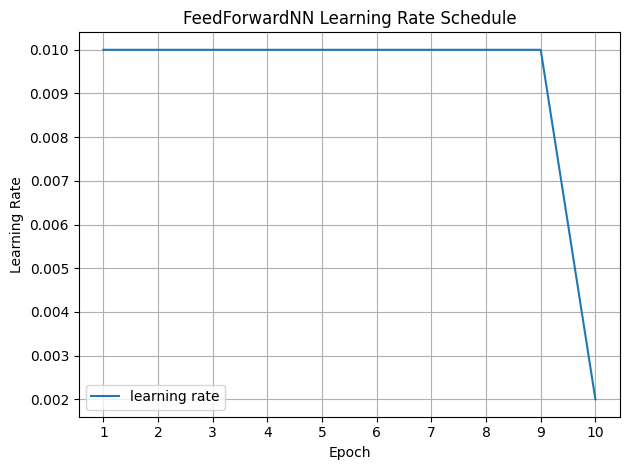

In [27]:
plot_learning_rates(
    model_ff,
    config=config,
    model_name="model_ff",
)

---

### **T8.**
What makes the learning rate change?
(hint: try to understand the scheduler [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html))


**Ans:** According to the PyTorch documentation:

> Reduce learning rate when a metric has stopped improving.
>
> Models often benefit from reducing the learning rate by a factor of 2-10 once learning stagnates. This scheduler reads a metrics quantity and if no improvement is seen for a ‘patience’ number of epochs, the learning rate is reduced.

The learning rate changes based on the performance of the model on the validation set. The `ReduceLROnPlateau` scheduler reduces the learning rate when a metric (in this case, validation loss) has stopped improving. If the validation loss does not improve for a certain number of epochs (patience), the learning rate will be reduced by a factor (e.g., 0.1). This helps the model to converge better by allowing it to take smaller steps when it is close to a minimum in the loss landscape.

---

## **Load Model**

Use the code snippet below to load the model you just trained

In [28]:
checkpoint = torch.load("models/model_ff.pth.tar")

# Create model object
loaded_model = FeedForwardNN(hidden_size=config["hidden_size"])

# Load weights
loaded_model.load_state_dict(checkpoint["model"])

print(f"Loaded epoch {checkpoint['epoch']} model")

Loaded epoch 5 model


---

## **A more complex scheduling**

The scheduler can be very complicated and you can write your own heuristic for it.

### **T9.**

Implement a custom learning rate scheduler that behaves like the following graph.

You might want to learn how to use [PyTorch's built-in learning rate schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) in order to build your own.

Learning rate should be function of epoch.

![](../images/LearningRateSchedule.png)

In [29]:
# Implement scheduler here
class MyScheduler():
    def __init__(
        self,
        optimizer: torch.optim.Optimizer
    ):
        self.optimizer = optimizer

    def step(self, epoch):
        # Changes the learning rate here
        lr_inclement = 0
        if epoch <= 3:
            lr_inclement = 0.0003
        elif epoch <= 6:
            lr_inclement = -0.0001 * 5/3
        elif epoch <= 7:
            lr_inclement = 0.0005
        elif epoch <= 9:
            lr_inclement = -0.00045
        else:
            lr_inclement = 0
        
        for param_group in self.optimizer.param_groups:
            if epoch == 0:
                param_group["lr"] = 0.0001
            else:
                param_group["lr"] += lr_inclement

In [30]:
# Now train with your scheduler
model = torch.nn.Linear(10, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0)

my_scheduler = MyScheduler(optimizer)

num_epochs = 10
lr_history = []

for epoch in range(num_epochs):
    optimizer.step()
    my_scheduler.step(epoch)

    lr = my_scheduler.optimizer.param_groups[0]["lr"]
    lr_history.append(lr)

    print(f"Epoch {epoch:02d} | LR = {lr:.6f}")

Epoch 00 | LR = 0.000100
Epoch 01 | LR = 0.000400
Epoch 02 | LR = 0.000700
Epoch 03 | LR = 0.001000
Epoch 04 | LR = 0.000833
Epoch 05 | LR = 0.000667
Epoch 06 | LR = 0.000500
Epoch 07 | LR = 0.001000
Epoch 08 | LR = 0.000550
Epoch 09 | LR = 0.000100


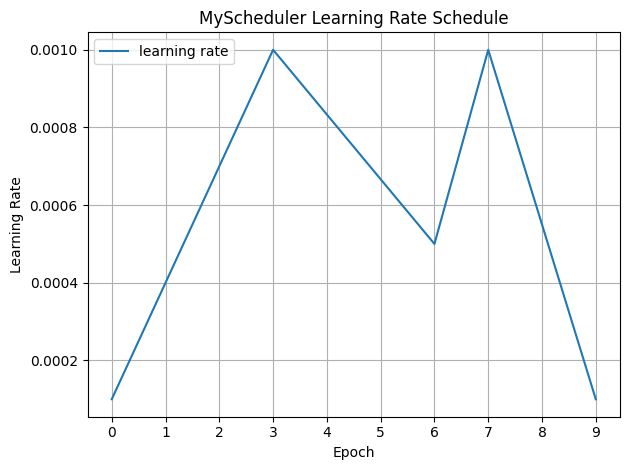

In [31]:
plt.plot(range(num_epochs), lr_history, label="learning rate")
plt.xticks(range(num_epochs))
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("MyScheduler Learning Rate Schedule")

plt.tight_layout()
plt.legend()
plt.grid()

plt.savefig("../images/MyLearningRateSchedule.png")
plt.show()

---

## **<u>[Optional]</u> Wandb**

You should now have a project in wandb with the name `precipitation-nowcasting`, which you should see the latest run you just finished inside the project. If you look into the run, you should be able to see plots of learning rate, train loss, val loss in the `Charts` section. Below it should be `Gradients` and `Parameters` section.

### **[Wandb Observation] OT1.**
Write your own interpretation of the logs from this example. A simple sentence or two for each section is sufficient.

**Your answer:**
- **Charts**: The training loss and validation loss are plotted against the number of epochs. The learning rate is also plotted, showing how it changes over time.
- **Gradients**: The distribution of gradients for each layer is plotted. This can help us understand if the model is learning properly or if there are issues such as vanishing or exploding gradients.
- **Parameters**: The distribution of parameters (weights) for each layer is plotted. This can help us understand if the weights are being updated properly during training and if there are any issues such as weights becoming too large or too small.

---

## **Evaluation**

### **Function:** `evaluate()`

In [32]:
################################################################################
# T10:                                                                         #
# Write a function to evaluate your model. Your function must predicts         #
# using the input model and return mean square error of the model.             #
#                                                                              #
# Hint: Read how to use PyTorch's MSE Loss                                     #
# https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html              #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

def evaluate(data_loader, model):
    model.eval()
    mse_fn = nn.MSELoss()
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for inputs, y_true in tqdm(data_loader):
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            y_pred = model(inputs)

            y_true_list.append(y_true)
            y_pred_list.append(y_pred)

    y_true_all = torch.cat(y_true_list, dim=0)
    y_pred_all = torch.cat(y_pred_list, dim=0)

    mse = mse_fn(y_pred_all, y_true_all)
    return mse

### **Function:** `majority_baseline()`

In [33]:
# We will use majority rule as a baseline.
def majority_baseline(label_set):
    unique, counts = np.unique(label_set, return_counts=True)
    majority = unique[np.argmax(counts)]
    baseline = 0
    
    label_set = label_set.reshape(-1, 1)
    for r in label_set:
        baseline += (majority - r) ** 2 / len(label_set)
    
    return baseline

### **Function:** `print_evaluation()`

In [34]:
def print_evaluation(
    model,
    model_name,
    config,
    mode="train",
    is_return=False,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
):
    if mode not in ["train", "test", "all"]:
        raise ValueError("Invalid mode. Choose from 'train', 'test', 'all'.")
    
    print("baseline")
    if mode in ["train", "all"]:
        print("train", majority_baseline(y_train))
        print("validate", majority_baseline(y_val))
        
    if mode in ["test", "all"]:
        print("test", majority_baseline(y_test))
    
    wandb.init(
        project="precipitation-nowcasting-2026",
        config=config,
    )

    model, _, _, _ = load_model(model, model_dir="models/", model_name=model_name)
    
    print(model_name)
    if mode in ["train", "all"]:
        train_mse = evaluate(train_loader, model).item()
        val_mse = evaluate(val_loader, model).item()
        test_mse = None
        
        print("train", train_mse)
        print("validate", val_mse)
        
    if mode in ["test", "all"]:
        train_mse = None
        val_mse = None
        test_mse = evaluate(test_loader, model).item()
        
        print("test", test_mse)

    wandb.finish()
    
    return train_mse, val_mse, test_mse if is_return else None, None, None

---

In [35]:
print_evaluation(
    model_ff,
    "model_ff",
    config=config,
    mode="train",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
)

baseline
train [1.94397725]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nodahttap/.netrc.


validate [1.6746546]


wandb: Currently logged in as: patthadon-1807 (patthadon-1807-chulalongkorn-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


model_ff


100%|██████████| 454/454 [00:32<00:00, 14.11it/s]


train 1.923689603805542
validate 1.6628518104553223


(1.923689603805542, 1.6628518104553223, None, None, None)

---

## **Dropout**

You might notice that the 3-layered feedforward does not use dropout at all. Now, try adding dropout (dropout rate of 20%) to the model, run, and report the result again.

To access PyTorch's dropout, use `nn.Dropout`. Read more about PyTorch's built-in Dropout layer [here](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [36]:
################################################################################
# T11:                                                                         #
# Write a feedforward model with dropout                                       #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class FeedForwardNN_Dropout(nn.Module):
    def __init__(self, hidden_size=200, dropout_rate=0.2):
        super(FeedForwardNN_Dropout, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1 = F.relu(self.ff1(x))
        hd1 = self.dropout(hd1)
        hd2 = F.relu(self.ff2(hd1))
        hd2 = self.dropout(hd2)
        y = F.relu(self.ff3(hd2))
        y = self.dropout(y)
        y = self.out(y)
        
        return y.reshape(-1, 1)

Model Config: {'dropout_rate': 0.2, 'hidden_size': 200}


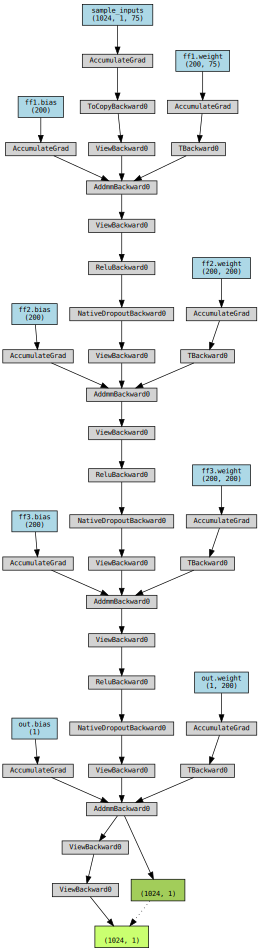

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN_Dropout                    [1024, 1]                 --
├─Linear: 1-1                            [1024, 200]               15,200
├─Dropout: 1-2                           [1024, 200]               --
├─Linear: 1-3                            [1024, 200]               40,200
├─Dropout: 1-4                           [1024, 200]               --
├─Linear: 1-5                            [1024, 200]               40,200
├─Dropout: 1-6                           [1024, 200]               --
├─Linear: 1-7                            [1024, 1]                 201
Total params: 95,801
Trainable params: 95,801
Non-trainable params: 0
Total mult-adds (M): 98.10
Input size (MB): 0.31
Forward/backward pass size (MB): 4.92
Params size (MB): 0.38
Estimated Total Size (MB): 5.61

In [37]:
model_config = ModelConfig({"dropout_rate": 0.2}, FeedForwardNN_Dropout)
config_dropout, model_ff_dropout, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_loader, save_png=True, save_name="FeedForwardNN_Dropout", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 75))

In [38]:
################################################################################
# T12:                                                                         #
# Complete the code to train your dropout model                                #
################################################################################

print("start training ff dropout")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

train_losses, val_losses, learning_rates = train_model(
    config_dropout,
    model_ff_dropout,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    model_name="model_ff_dropout"
)

start training ff dropout
Skipping training for model_ff_dropout as TraingSkip is set to True.


---

### **T13.**
Plot the losses and MSE of the training and validation as before. Evaluate the dropout model's performance

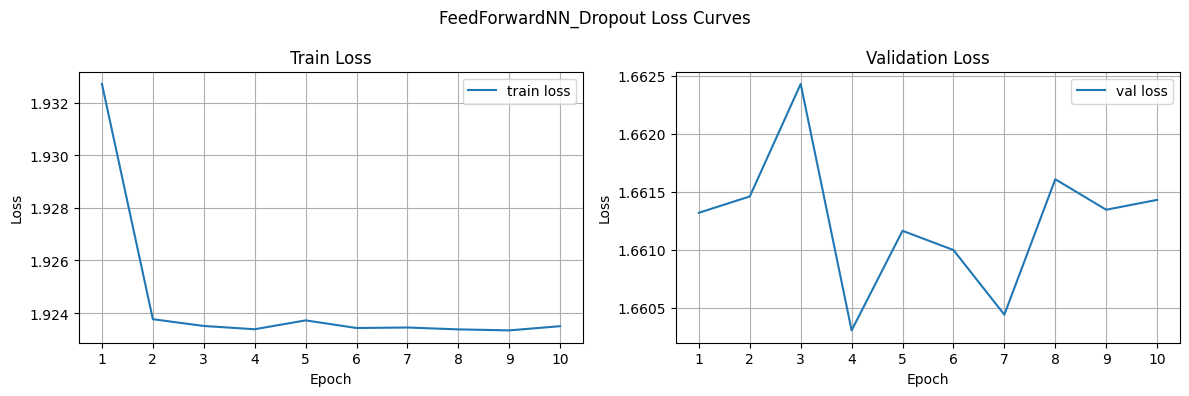

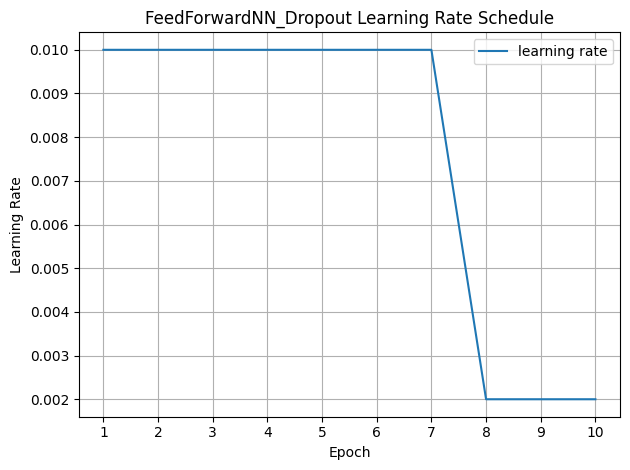

In [39]:
# Plot here
plot_losses(
    model_ff_dropout,
    config=config_dropout,
    model_name="model_ff_dropout",
)

plot_learning_rates(
    model_ff_dropout,
    config=config_dropout,
    model_name="model_ff_dropout",
)

In [40]:
print_evaluation(
    model_ff_dropout,
    "model_ff_dropout",
    config=config_dropout,
    mode="train",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
)

baseline
train [1.94397725]
validate [1.6746546]


model_ff_dropout


100%|██████████| 454/454 [00:32<00:00, 14.06it/s]

train 1.9204503297805786
validate 1.6605135202407837


(1.9204503297805786, 1.6605135202407837, None, None, None)

---

## **Convolution Neural Networks**
Now let's try to incorporate the grid sturcture to your model. Instead of passing in vectors, we are going to pass in the 5x5 grid into the model (5 lat x 5 long x 3 channel). You are going to implement you own 2d-convolution neural networks with the following structure.

```
========================================================================================== 
Layer (type:depth-idx)                   Output Shape              Param
========================================================================================== 
Conv2DNN                                 --                        -- 
├─Conv2d: 1-1                            [1024, 200, 3, 3]         5,600 
├─Linear: 1-2                            [1024, 200]               360,200 
├─Linear: 1-3                            [1024, 200]               40,200 
├─Linear: 1-4                            [1024, 1]                 201 
========================================================================================== 
Total params: 406,201 
Trainable params: 406,201
Non-trainable params: 0
```

These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         

Hint: You should read PyTorch documentation to see the list of available layers and options you can use.                         

In [41]:
################################################################################
# T14:                                                                         #
# Complete the code for preparing data for training CNN                        #
# Input for CNN should not have time step.                                     #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

from torch.utils.data import Dataset

class ConvDataset(Dataset):
    def __init__(self, X, y):
        X = torch.as_tensor(X, dtype=torch.float32)
        mean = X.mean(dim=0, keepdim=True)
        std = X.std(dim=0, keepdim=True) + 1e-8
        self.X = (X - mean) / std
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].view(3, 5, 5)
        y = self.y[idx]
        return x, y

train_dataset_conv = ConvDataset(x_train_ff, y_train_ff)
val_dataset_conv   = ConvDataset(x_val_ff, y_val_ff)
test_dataset_conv  = ConvDataset(x_test_ff, y_test_ff)

train_conv_loader = DataLoader(train_dataset_conv, batch_size=1024, shuffle=True, pin_memory=True)
val_conv_loader = DataLoader(val_dataset_conv, batch_size=1024, shuffle=False, pin_memory=True)
test_conv_loader = DataLoader(test_dataset_conv, batch_size=1024, shuffle=False, pin_memory=True)

In [42]:
################################################################################
# T15:                                                                         #
# Write a PyTorch convolutional neural network model.                          #
# You might want to use the layer torch.flatten somewhere                      #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class FeedForwardNN_Convolution(nn.Module):
    def __init__(self, hidden_size=200, kernel_size=3):
        super(FeedForwardNN_Convolution, self).__init__()
        self.conv1 = nn.Conv2d(3, hidden_size, kernel_size=kernel_size)
        self.ff1 = nn.Linear(hidden_size * kernel_size * kernel_size, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        conv_out = self.conv1(x)
        conv_out = torch.flatten(conv_out, start_dim=1)
        hd1 = F.relu(self.ff1(conv_out))
        y = F.relu(self.ff2(hd1))
        y = self.out(y)
        
        return y.reshape(-1, 1)

Model Config: {'kernel_size': 3, 'hidden_size': 200}


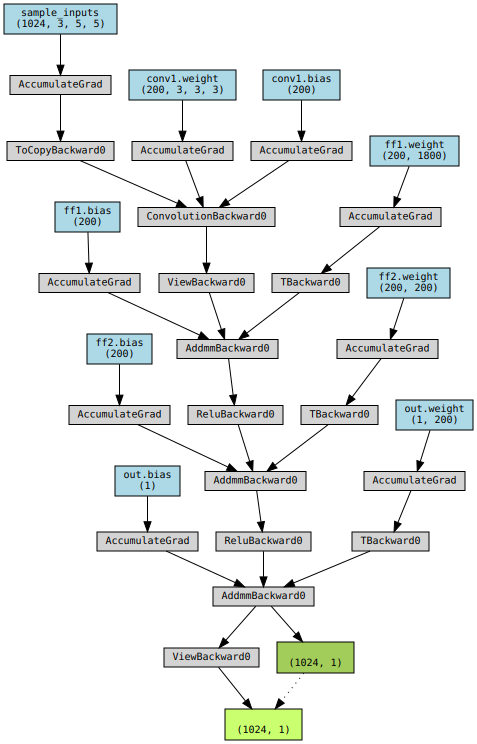

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN_Convolution                [1024, 1]                 --
├─Conv2d: 1-1                            [1024, 200, 3, 3]         5,600
├─Linear: 1-2                            [1024, 200]               360,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
Total params: 406,201
Trainable params: 406,201
Non-trainable params: 0
Total mult-adds (M): 461.83
Input size (MB): 0.31
Forward/backward pass size (MB): 18.03
Params size (MB): 1.62
Estimated Total Size (MB): 19.96

In [43]:
model_config = ModelConfig({"kernel_size": 3}, FeedForwardNN_Convolution)
config_conv, model_ff_conv, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_conv_loader, save_png=True, save_name="FeedForwardNN_Convolution", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 3, 5, 5))

In [44]:
################################################################################
# T16:                                                                         #
# Complete the code to train your cnn model                                    #
################################################################################

print("start training conv2d")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
train_losses, val_losses, learning_rates = train_model(
    config_conv,
    model_ff_conv,
    optimizer,
    scheduler,
    train_conv_loader,
    val_conv_loader,
    model_name="model_ff_convolution"
)

start training conv2d
Skipping training for model_ff_convolution as TraingSkip is set to True.


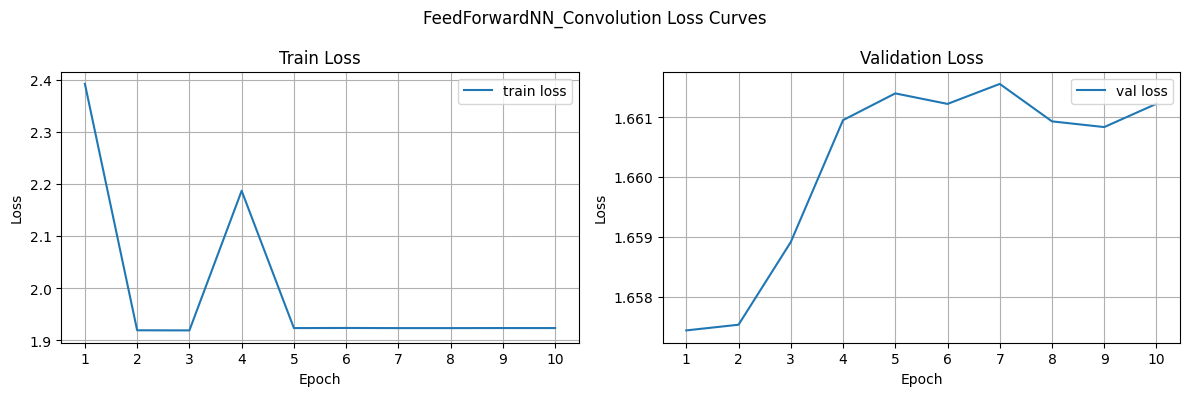

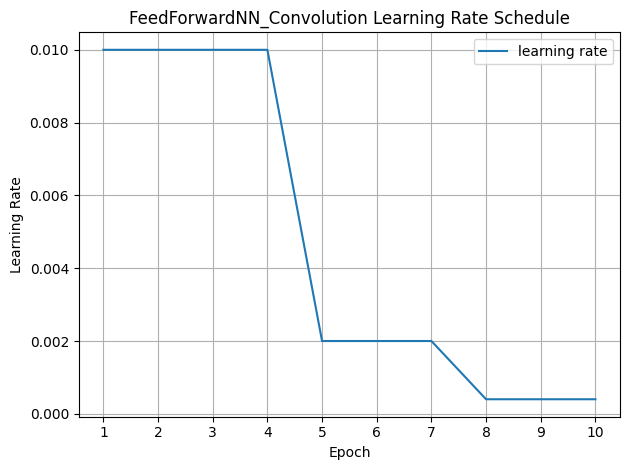

In [45]:
# Plot losses
plot_losses(
    model_ff_conv,
    config=config_conv,
    model_name="model_ff_convolution",
)

plot_learning_rates(
    model_ff_conv,
    config=config_conv,
    model_name="model_ff_convolution",
)

In [46]:
# Evaluate
print_evaluation(
    model_ff_conv,
    "model_ff_convolution",
    config=config_conv,
    mode="train",
    train_loader=train_conv_loader,
    val_loader=val_conv_loader,
    test_loader=test_conv_loader
)

baseline
train [1.94397725]
validate [1.6746546]


model_ff_convolution


100%|██████████| 454/454 [00:04<00:00, 104.59it/s]

train 1.9189356565475464
validate 1.6598892211914062


(1.9189356565475464, 1.6598892211914062, None, None, None)

---

## **<u>[Optional]</u> Gated Recurrent Units**

Now, you want to add time steps into your model. Recall the original data has 5 time steps per item. You are going to pass in a data of the form 5 timesteps x 75 data. This can be done using a GRU layer. Implement you own GRU network with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
GRUModel                                 --                        --
├─GRU: 1-1                               [1024, 5, 200]            166,200
├─Linear: 1-2                            [1024, 5, 200]            40,200
├─Linear: 1-3                            [1024, 5, 1]              201
==========================================================================================
Total params: 206,601
Trainable params: 206,601
Non-trainable params: 0
```


These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         
The result should be better than the feedforward model and at least on par with your CNN model.    

Do consult PyTorch documentation on how to use [GRUs](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html).

In [41]:
################################################################################
# OT2:                                                                         #
# Complete the code for preparing data for training GRU                        #
# GRU's input should has 3 dimensions.                                         #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

from torch.utils.data import Dataset

class GRUDataset(Dataset):
    def __init__(self, X, y, hidden_size=200):
        X = torch.as_tensor(X, dtype=torch.float32)
        mean = X.mean(dim=0, keepdim=True)
        std = X.std(dim=0, keepdim=True) + 1e-8
        self.X = (X - mean) / std
        self.y = torch.as_tensor(y, dtype=torch.float32)
        self.hidden_size = hidden_size

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].view(5, 15)
        y = self.y[idx]
        return x, y

train_dataset_gru = GRUDataset(x_train_ff, y_train_ff)
val_dataset_gru   = GRUDataset(x_val_ff, y_val_ff)
test_dataset_gru  = GRUDataset(x_test_ff, y_test_ff)

train_gru_loader = DataLoader(train_dataset_gru, batch_size=1024, shuffle=True, pin_memory=True)
val_gru_loader = DataLoader(val_dataset_gru, batch_size=1024, shuffle=False, pin_memory=True)
test_gru_loader = DataLoader(test_dataset_gru, batch_size=1024, shuffle=False, pin_memory=True)

In [42]:
################################################################################
# OT3:                                                                         #
# Write a PyTorch GRU model.                                                   #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class FeedForwardNN_GRU(nn.Module):
    def __init__(self, hidden_size=200, steps=5):
        super(FeedForwardNN_GRU, self).__init__()
        self.gru = nn.GRU(15, hidden_size, batch_first=True)
        self.ff1 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1, _ = self.gru(x)
        hd1 = hd1[:, -1, :]
        hd1 = F.relu(hd1)
        y = F.relu(self.ff1(hd1))
        y = self.out(y)
        
        return y.reshape(-1, 1)

Model Config: {'steps': 5, 'hidden_size': 200}


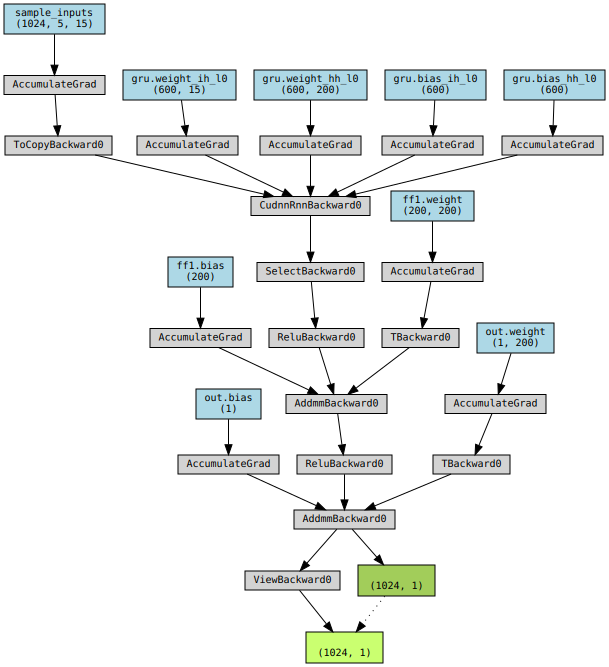

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN_GRU                        [1024, 1]                 --
├─GRU: 1-1                               [1024, 5, 200]            130,200
├─Linear: 1-2                            [1024, 200]               40,200
├─Linear: 1-3                            [1024, 1]                 201
Total params: 170,601
Trainable params: 170,601
Non-trainable params: 0
Total mult-adds (M): 707.99
Input size (MB): 0.31
Forward/backward pass size (MB): 9.84
Params size (MB): 0.68
Estimated Total Size (MB): 10.83

In [43]:
model_config = ModelConfig({"steps": 5}, FeedForwardNN_GRU)
config_gru, model_ff_gru, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_gru_loader, save_png=True, save_name="FeedForwardNN_GRU", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 5, 15))

In [44]:
################################################################################
# OT4:                                                                         #
# Complete the code to train your gru model                                    #
################################################################################

print("start training gru")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

train_losses, val_losses, learning_rates = train_model(
    config_gru,
    model_ff_gru,
    optimizer,
    scheduler,
    train_gru_loader,
    val_gru_loader,
    model_name="model_ff_gru"
)

start training gru
Skipping training for model_ff_gru as TraingSkip is set to True.


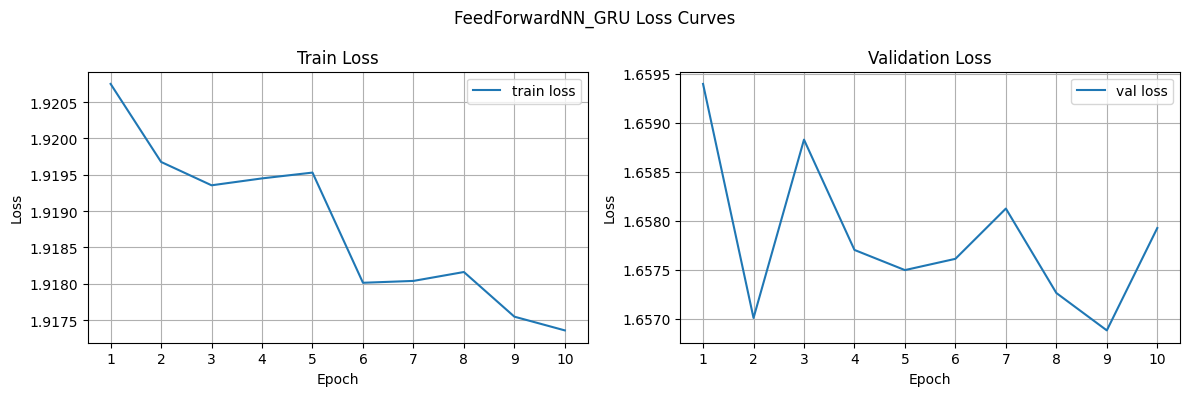

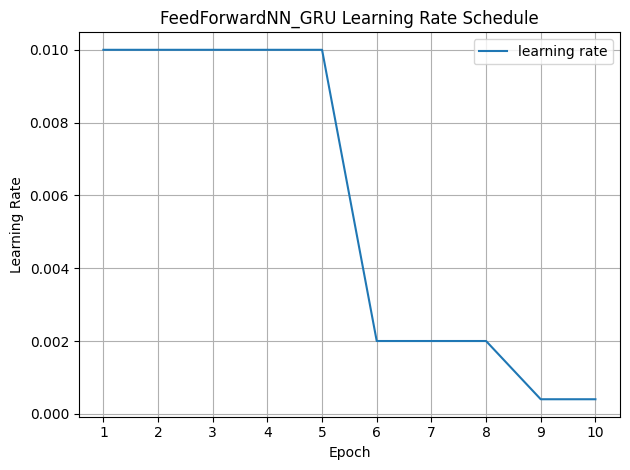

In [45]:
# Plot losses
plot_losses(
    model_ff_gru,
    config=config_gru,
    model_name="model_ff_gru",
)

plot_learning_rates(
    model_ff_gru,
    config=config_gru,
    model_name="model_ff_gru",
)

In [46]:
# Evaluate
print_evaluation(
    model_ff_gru,
    "model_ff_gru",
    config=config_gru,
    mode="train",
    train_loader=train_gru_loader,
    val_loader=val_gru_loader,
    test_loader=test_gru_loader
)

baseline
train [1.94397725]
validate [1.6746546]


model_ff_gru


100%|██████████| 454/454 [00:03<00:00, 115.05it/s]

train 1.9174836874008179
validate 1.6593255996704102


(1.9174836874008179, 1.6593255996704102, None, None, None)

---

## **Transformer**

Welcome to the beginning of the real world! The aboved models are not usually used in practice due to its limited capability. Transformers are generally used by computer vision, natural language processing, and speech processing (almost every big AI fields).



In our dataloader, we will add the output of this timestep (the number of precipitation) as an auxiliary input to predict the next timestep. Thus, input for the model should be [#batch_size, 5, 76] (5 timesteps and the number 76 comes from (3 x 5 x 5) + 1) and the output for the model should be [#batch_size, 1] which would be the next timestep we want to predict. Additionally, we will mask the input at the dataloader to the attenttion from observing future values. Suppose that we want to predict timestep 3, we will mask the timestep 3, 4 and 5 in our input by setting it to zeros, and we will predict the timestep 3.

In order to get a score on this TODO, students need to implement a dataloader that mask the input correctly.

(Note, in this homework, we ask you to mask the input which is simple to do. In practice, people prefer to mask the attention mask instead. This makes decoder-only architectures more parallelizable.)

In [47]:
################################################################################
# T17:                                                                         #
# Complete the code for preparing data for training Transformer                #
# Transformer's input should has 3 dimensions.                                 #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

from torch.utils.data import Dataset

class TransformerDataset(Dataset):
    def __init__(self, X, y, seq_len=5):
        X = torch.as_tensor(X, dtype=torch.float32)
        mean = X.mean(dim=0, keepdim=True)
        std = X.std(dim=0, keepdim=True) + 1e-8
        X = (X - mean) / std
        
        y = torch.as_tensor(y, dtype=torch.float32)

        X_seq = X.unfold(0, seq_len, 1).permute(0, 2, 1)
        y_hist = y.unfold(0, seq_len, 1).permute(0, 2, 1)
        y_target = y[seq_len - 1:]

        self.X = torch.cat([X_seq, y_hist], dim=-1).contiguous()
        self.y = y_target.contiguous()

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset_transformer = TransformerDataset(x_train_ff, y_train_ff)
val_dataset_transformer   = TransformerDataset(x_val_ff, y_val_ff)
test_dataset_transformer  = TransformerDataset(x_test_ff, y_test_ff)

train_transformer_loader = DataLoader(train_dataset_transformer, batch_size=1024, shuffle=True, pin_memory=True)
val_transformer_loader = DataLoader(val_dataset_transformer, batch_size=1024, shuffle=False, pin_memory=True)
test_transformer_loader = DataLoader(test_dataset_transformer, batch_size=1024, shuffle=False, pin_memory=True)

: 


In this task, we will implement one encoder layer of Transformer and add the linear layer to make a regression prediction. For the simplicity of the model, we will change the multi-head attention to QKV self-attention (single-head). As a result, our model should look like the diagram below. Since the layer self-attention is not availble in torch, students have to implement it themselves. In Add & Norm layer, students have to do the addition before normalizing. In Layer Normalization, we will normalize across both timesteps and features.

If you feel loss in this part of the assignment, watching this [video](https://www.youtube.com/watch?v=kCc8FmEb1nY) might help.

![](../images/TransformerArchitecture.png)

```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
TransformerModel                         [1024, 1]                 --
├─PositionalEncoding: 1-1                [1024, 5, 76]             --
│    └─Dropout: 2-1                      [1024, 5, 76]             --
├─SelfAttention: 1-2                     [1024, 5, 76]             --
│    └─Linear: 2-2                       [1024, 5, 76]             5,852
│    └─Linear: 2-3                       [1024, 5, 76]             5,852
│    └─Linear: 2-4                       [1024, 5, 76]             5,852
│    └─Softmax: 2-5                      [1024, 5, 5]              --
├─LayerNorm: 1-3                         [1024, 5, 76]             760
├─Linear: 1-4                            [1024, 5, 76]             5,852
├─LayerNorm: 1-5                         [1024, 5, 76]             760
├─Linear: 1-6                            [1024, 1]                 381
==========================================================================================
Total params: 25,309
Trainable params: 25,309
Non-trainable params: 0
Total mult-adds (M): 25.92
==========================================================================================
Input size (MB): 1.56
Forward/backward pass size (MB): 18.69
Params size (MB): 0.10
Estimated Total Size (MB): 20.34
==========================================================================================
```

In [ ]:
################################################################################
# T18                                                                          #
# Write a PyTorch PositionalEncoding Layer.                                    #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

import math

class PositionalEncoding(nn.Module):
  def __init__(self, seq_len, emb_dim, dropout=0.2):
    super(PositionalEncoding, self).__init__()
    self.dropout = nn.Dropout(dropout)
    
    pe = torch.zeros(seq_len, emb_dim)
    position = torch.arange(0, seq_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, emb_dim, 2) * (-math.log(10000.0) / emb_dim)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    pe = pe.unsqueeze(0)
    
    self.register_buffer("pe", pe)
    self.pe = pe

  def forward(self, x):
    x = x + self.pe[:, :x.size(1)]
    
    return self.dropout(x)

In [ ]:
################################################################################
# T19                                                                          #
# Write a PyTorch Transformer model.                                           #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class SelfAttention(nn.Module):
  def __init__(self, input_dim):
    super(SelfAttention, self).__init__()
    self.q = nn.Linear(input_dim, input_dim)
    self.k = nn.Linear(input_dim, input_dim)
    self.v = nn.Linear(input_dim, input_dim)
    self.softmax = nn.Softmax(dim=-1)

  def forward(self, x):
    B, T, C = x.shape
    
    Q = self.q(x)
    K = self.k(x)
    V = self.v(x)
    
    attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(x.size(-1))
    
    mask = torch.tril(torch.ones(T, T, device=x.device))
    attn_scores = attn_scores.masked_fill(mask == 0, float("-inf"))
    
    attn_weights = self.softmax(attn_scores)
    attn_output = torch.matmul(attn_weights, V)
    
    return attn_output


class TransformerModel(nn.Module):
  def __init__(self, hidden_size=200, seq_len=5, emb_dim=76):
    super(TransformerModel, self).__init__()
    self.pos_encoder = PositionalEncoding(seq_len=seq_len, emb_dim=emb_dim)
    self.attention = SelfAttention(input_dim=emb_dim)
    
    self.norm1 = nn.LayerNorm(emb_dim)
    self.ff1 = nn.Linear(emb_dim, emb_dim)
    self.norm2 = nn.LayerNorm(emb_dim)
    self.fc_out = nn.Linear(emb_dim, 1)

  def forward(self, x):
    x = self.pos_encoder(x)
    attn_output = self.attention(x)
    x = self.norm1(x + attn_output)
    
    ff_output1 = F.relu(self.ff1(x))
    x = self.norm2(x + ff_output1)
    
    out = self.fc_out(x[:, -1, :])
    
    return out.reshape(-1, 1)

Model Config: {'seq_len': 5, 'emb_dim': 76, 'hidden_size': 200}


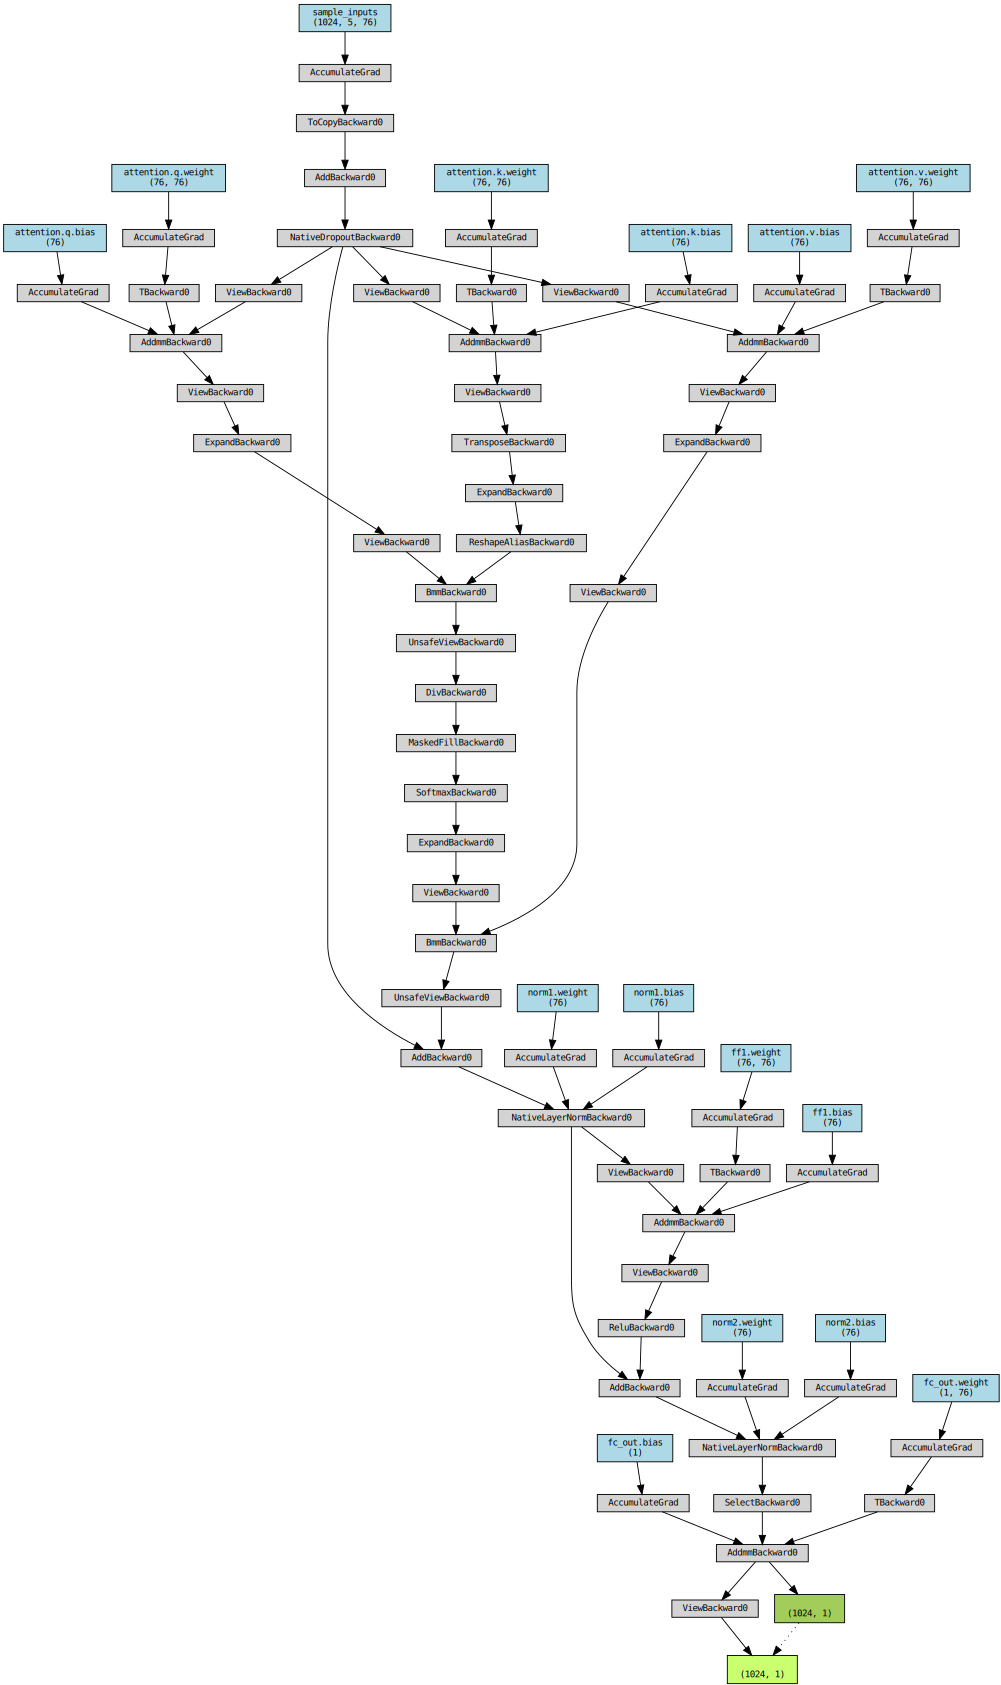

Layer (type:depth-idx)                   Output Shape              Param #
TransformerModel                         [1024, 1]                 --
├─PositionalEncoding: 1-1                [1024, 5, 76]             --
│    └─Dropout: 2-1                      [1024, 5, 76]             --
├─SelfAttention: 1-2                     [1024, 5, 76]             --
│    └─Linear: 2-2                       [1024, 5, 76]             5,852
│    └─Linear: 2-3                       [1024, 5, 76]             5,852
│    └─Linear: 2-4                       [1024, 5, 76]             5,852
│    └─Softmax: 2-5                      [1024, 5, 5]              --
├─LayerNorm: 1-3                         [1024, 5, 76]             152
├─Linear: 1-4                            [1024, 5, 76]             5,852
├─LayerNorm: 1-5                         [1024, 5, 76]             152
├─Linear: 1-6                            [1024, 1]                 77
Total params: 23,789
Trainable params: 23,789
Non-trainable params: 0
T

In [ ]:
model_config = ModelConfig({"seq_len": 5, "emb_dim": 76}, TransformerModel)
config_transformer, model_transformer, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_transformer_loader, save_png=True, save_name="TransformerModel", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 5, 76))

In [ ]:
################################################################################
# T20                                                                          #
# Complete the code to train your Transformer model                            #
################################################################################

print("start training transformer")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

train_losses, val_losses, learning_rates = train_model(
    config_transformer,
    model_transformer,
    optimizer,
    scheduler,
    train_transformer_loader,
    val_transformer_loader,
    model_name="model_transformer"
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nodahttap/.netrc.


start training transformer


wandb: Currently logged in as: patthadon-1807 (patthadon-1807-chulalongkorn-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training epoch 1...
Current LR: 0.01


 22%|██▏       | 243/1121 [00:34<00:19, 46.01it/s]

: 

In [ ]:
# Plot losses
plot_losses(
    model_transformer,
    config=config_transformer,
    model_name="model_transformer",
)

plot_learning_rates(
    model_transformer,
    config=config_transformer,
    model_name="model_transformer",
)

If you implement it correctly, you should evaluate the model in the test dataset and the score should be better than the aboved models.

In [ ]:
# Evaluate
print_evaluation(
    model_transformer,
    "model_transformer",
    config=config_transformer,
    mode="train",
    train_loader=train_transformer_loader,
    val_loader=val_transformer_loader,
    test_loader=test_transformer_loader
)

---

## **Final Section - PyTorch Playground**

Now, train the best model you can do for this task. You can use any model structure and function available.    
Remember that trainig time increases with the complexity of the model. You might find printing computation graphs helpful in debugging complicated models.    
Your model should be better than your CNN or Transformer model in the previous sections.

Some ideas:
- Tune the hyperparameters
- Adding dropouts
- Combining different types of models

You should tune your model on training and validation set.    
**The test set should be used only for the last evaluation.**

In [ ]:
# Prep data as you see fit

class MyModelDataset(Dataset):
    def __init__(self, X, y, seq_len=5):
        X = torch.as_tensor(X, dtype=torch.float32)
        y = torch.as_tensor(y, dtype=torch.float32)

        self.seq_len = seq_len

        X_seq = X.unfold(0, seq_len, 1).permute(0, 2, 1)
        y_hist = y.unfold(0, seq_len, 1).permute(0, 2, 1)
        y_target = y[seq_len - 1:]

        self.X = torch.cat([X_seq, y_hist], dim=-1).contiguous()
        self.y = y_target.contiguous()

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_my_model = MyModelDataset(x_train_ff, y_train_ff)
val_dataset_my_model   = MyModelDataset(x_val_ff, y_val_ff)
test_dataset_my_model  = MyModelDataset(x_test_ff, y_test_ff)

train_my_model_loader = DataLoader(train_dataset_my_model, batch_size=1024, shuffle=True, pin_memory=True)
val_my_model_loader = DataLoader(val_dataset_my_model, batch_size=1024, shuffle=False, pin_memory=True)
test_my_model_loader = DataLoader(test_dataset_my_model, batch_size=1024, shuffle=False, pin_memory=True)

In [ ]:
################################################################################
# T21                                                                          #
# Write a function that returns your best PyTorch model. You can use anything  #
# you want. The goal here is to create the best model you can think of.        #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################


################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class CNN_GRU_Model(nn.Module):
    def __init__(self, hidden_size=256, gru_hidden=256, dropout=0.2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.feature_dim = 64 + 1

        self.gru = nn.GRU(
            input_size=self.feature_dim,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.LayerNorm(gru_hidden),
            nn.Linear(gru_hidden, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        B, T, C = x.shape

        spatial = x[:, :, :-1].contiguous().view(B * T, 3, 5, 5)
        precip  = x[:, :, -1:].contiguous().view(B, T, 1)

        spatial_feat = self.conv(spatial)
        spatial_feat = spatial_feat.view(B, T, -1)

        combined = torch.cat([spatial_feat, precip], dim=-1)

        gru_out, _ = self.gru(combined)
        last_hidden = gru_out[:, -1, :]

        return self.head(last_hidden)

In [ ]:
model_config = ModelConfig({"hidden_size": 256, "gru_hidden": 256, "dropout": 0.2}, CNN_GRU_Model)
config_my_model, model_my_model, optimizer, scheduler = model_config.get_config()

dot = model_config.make_dot(train_my_model_loader, save_png=True, save_name="MyModel", save_dir="../images/model_architecture/")
summary_text = model_config.print_summary(input_size=(1024, 5, 76))

In [ ]:
################################################################################
# T22                                                                          #
# Complete the code to train your best model                                   #
################################################################################

print("start training the best model")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

train_losses, val_losses, learning_rates = train_model(
    config_my_model,
    model_my_model,
    optimizer,
    scheduler,
    train_my_model_loader,
    val_my_model_loader,
    model_name="model_my_model"
)

In [ ]:
# Evaluate best model on validation and test set
print_evaluation(
    model_my_model,
    "model_my_model",
    config=config_my_model,
    mode="all",
    train_loader=train_my_model_loader,
    val_loader=val_my_model_loader,
    test_loader=test_my_model_loader,
)

---

## **Evaluation and Comparison**

In [ ]:
score_df = pd.DataFrame()
score_df.columns = ["model", "train_mse", "val_mse", "test_mse"]

---

### **Helper Functions**

In [ ]:
def save_losses_to_df(
    score_df,
    model,
    model_name,
    config,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
):
    train_loss, val_loss, test_loss = print_evaluation(
        model,
        model_name,
        config=config,
        mode="test",
        is_return=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
    )

    if score_df["model"].eq(model_name).any():
        score_df.drop(score_df[score_df["model"] == model_name].index, inplace=True)

    score_df = pd.concat([score_df, pd.DataFrame([{
        "model": model_name,
        "train_mse": train_loss,
        "val_mse": val_loss,
        "test_mse": test_loss
    }])], ignore_index=True)
    
    return score_df

---

In [ ]:
# Also evaluate your fully-connected model and CNN/GRU/Transformer model on the test set.
score_df = save_losses_to_df(
    score_df,
    model_ff,
    "model_ff",
    config=config,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
)

In [ ]:
score_df = save_losses_to_df(
    score_df,
    model_ff_dropout,
    "model_ff_dropout",
    config=config_dropout,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
)

In [ ]:
score_df = save_losses_to_df(
    score_df,
    model_ff_conv,
    "model_ff_convolution",
    config=config_conv,
    train_loader=train_conv_loader,
    val_loader=val_conv_loader,
    test_loader=test_conv_loader,
)

In [ ]:
score_df = save_losses_to_df(
    score_df,
    model_ff_gru,
    "model_ff_gru",
    config=config_gru,
    train_loader=train_gru_loader,
    val_loader=val_gru_loader,
    test_loader=test_gru_loader,
)

In [ ]:
score_df = save_losses_to_df(
    score_df,
    model_transformer,
    "model_transformer",
    config=config_transformer,
    train_loader=train_transformer_loader,
    val_loader=val_transformer_loader,
    test_loader=test_transformer_loader,
)

In [ ]:
score_df = save_losses_to_df(
    score_df,
    model_my_model,
    "model_my_model",
    config=config_my_model,
    train_loader=train_my_model_loader,
    val_loader=val_my_model_loader,
    test_loader=test_my_model_loader,
)

In [ ]:
score_df.to_csv("results/model_scores.csv", index=False)
score_df

To get full credit for this part, your best model should be better than the previous models on the **test set**.

---

### **T23.**
Explain what helped and what did not help here

**Ans:**

I've tried several approaches to improve the model's performance.
1. **Add more Layers:** Not helpful, it led to overfitting and did not improve the test score.
2. **Adding Dropout:** This was helpful in reducing overfitting and improved the test score.
3. **Hyperparameter Tuning:** This was helpful.

---

## **<u>[Optional]</u> Augmentation using data loader**

### **OT5.**
Implement a new dataloader on your best model that will perform data augmentation. Try adding noise of zero mean and variance of $ 10e^{-2} $.

Then, train your model.

In [ ]:
# Write Dataset/DataLoader with noise here


In [ ]:
print("start training the best model with noise")

################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
# Evaluate the best model trained with noise on validation and test set


---